# Notebook 04 — Batting Model
## IPL 2027 Franchise Squad Predictor

**Input:** `batting_labelled.parquet`  
**Output:** `models/batting_model.pkl`, `models/batting_features.pkl`

**Goal:** Train an XGBoost classifier that predicts whether a batsman will contribute to a match win, given only information available BEFORE that match.

**Key design rules:**
- Time-series split only — never random split on temporal data
- Train: 2016–2023 | Test: 2024–2025 (held out, never seen during training)
- XGBoost handles NaN natively — do not impute form features
- Evaluate on ROC-AUC and Precision-Recall, not just accuracy

---

## Step 0 — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, RocCurveDisplay
)


PROCESSED_DIR = r"E:\My ML Projects\2027 cricket squad prediction\data\processed"
MODELS_DIR    = r"E:\My ML Projects\2027 cricket squad prediction\models"


os.makedirs(MODELS_DIR, exist_ok=True)

batting = pd.read_parquet(PROCESSED_DIR + 'batting_labelled.parquet')

print(f'Batting labelled: {batting.shape}')
print(f'Seasons: {sorted(batting["season"].unique())}')
print(f'Target distribution:')
print(batting[batting['did_bat']==1]['contributed_to_win'].value_counts())

c:\Users\apecr\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\apecr\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Batting labelled: (9886, 40)
Seasons: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Target distribution:
contributed_to_win
0    7729
1    2151
Name: count, dtype: int64


In [2]:
import sys
print(sys.executable)

c:\Users\apecr\anaconda3\python.exe


In [1]:
import subprocess
subprocess.run([r"c:\Users\apecr\anaconda3\python.exe", "-m", "pip", "install", "numpy<2.0", "xgboost", "pyarrow", "numexpr"], check=True)

CompletedProcess(args=['c:\\Users\\apecr\\anaconda3\\python.exe', '-m', 'pip', 'install', 'numpy<2.0', 'xgboost', 'pyarrow', 'numexpr'], returncode=0)

## Step 1 — Select Features

Only features derived from PAST matches are allowed.
Current match stats (runs, balls_faced, strike_rate) are the outcome — never features.

In [3]:
# All candidates — we filter to only those that exist in the parquet
FEATURE_CANDIDATES = [
    # Recent form (exponentially weighted past matches)
    'form_runs',
    'form_strike_rate',
    'form_fours',
    'form_sixes',
    'form_boundary_rate',
    # Venue history
    'venue_avg_runs',
    'venue_avg_strike_rate',
    # Opponent matchup
    'vs_opp_avg_runs',
    'vs_opp_avg_strike_rate',
    # Reliability
    'consistency_runs',
    # Phase-specific past performance
    'phase_sr_Death',
    'phase_sr_Middle',
    'phase_sr_Powerplay',
    # Pressure & recency
    'pressure_sr',
    'recency_weight',
]

# Keep only columns that actually exist in the data
FEATURES = [f for f in FEATURE_CANDIDATES if f in batting.columns]
TARGET   = 'contributed_to_win'

print(f'Features selected : {len(FEATURES)}')
for f in FEATURES:
    null_pct = batting[f].isnull().mean() * 100
    print(f'  {f:35s}  NaN: {null_pct:.1f}%')

Features selected : 15
  form_runs                            NaN: 11.6%
  form_strike_rate                     NaN: 11.6%
  form_fours                           NaN: 11.6%
  form_sixes                           NaN: 11.6%
  form_boundary_rate                   NaN: 11.6%
  venue_avg_runs                       NaN: 41.2%
  venue_avg_strike_rate                NaN: 41.2%
  vs_opp_avg_runs                      NaN: 27.3%
  vs_opp_avg_strike_rate               NaN: 27.3%
  consistency_runs                     NaN: 11.6%
  phase_sr_Death                       NaN: 0.0%
  phase_sr_Middle                      NaN: 0.0%
  phase_sr_Powerplay                   NaN: 0.0%
  pressure_sr                          NaN: 84.7%
  recency_weight                       NaN: 0.0%


## Step 2 — Time-Series Train / Test Split

**Never use random split on time-series data.**  
A random split leaks future information into training — your model will look great in evaluation but fail completely in production.  

We train on 2016–2023, test on 2024–2025. This mirrors real-world use: train on everything you know, predict the future.

In [4]:
TRAIN_SEASONS = list(range(2016, 2024))   # 2016–2023
TEST_SEASONS  = [2024, 2025]              # held out

# Filter to only players who actually batted
batted = batting[batting['did_bat'] == 1].copy()

train = batted[batted['season'].isin(TRAIN_SEASONS)]
test  = batted[batted['season'].isin(TEST_SEASONS)]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'Train : {X_train.shape}  |  positive rate: {y_train.mean():.1%}')
print(f'Test  : {X_test.shape}   |  positive rate: {y_test.mean():.1%}')
print(f'\nTrain seasons : {TRAIN_SEASONS}')
print(f'Test seasons  : {TEST_SEASONS}')

Train : (7643, 15)  |  positive rate: 21.0%
Test  : (2237, 15)   |  positive rate: 24.3%

Train seasons : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Test seasons  : [2024, 2025]


## Step 3 — Handle Class Imbalance

With ~22% positive rate, XGBoost will lean toward predicting 0 (no contribution) for everything.
`scale_pos_weight` corrects this by telling XGBoost to penalise missing a positive case more heavily.

In [5]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = round(neg / pos, 2)

print(f'Train negatives (0) : {neg:,}')
print(f'Train positives (1) : {pos:,}')
print(f'scale_pos_weight    : {scale_pos_weight}')
print(f'(tells XGBoost: each positive case = {scale_pos_weight}x a negative case)')

Train negatives (0) : 6,036
Train positives (1) : 1,607
scale_pos_weight    : 3.76
(tells XGBoost: each positive case = 3.76x a negative case)


## Step 4 — Train XGBoost Model

In [6]:
model = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = 'logloss',
    early_stopping_rounds = 30,
    random_state      = 42,
    n_jobs            = -1,
)

model.fit(
    X_train, y_train,
    eval_set     = [(X_test, y_test)],
    verbose      = 50,
)

print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-logloss:0.67408
[50]	validation_0-logloss:0.47223
[100]	validation_0-logloss:0.45302
[150]	validation_0-logloss:0.44152
[200]	validation_0-logloss:0.43225
[250]	validation_0-logloss:0.42898
[300]	validation_0-logloss:0.42617
[350]	validation_0-logloss:0.42448
[399]	validation_0-logloss:0.42146

Best iteration: 398


## Step 5 — Evaluate on Test Set

In [7]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

roc_auc  = roc_auc_score(y_test, y_pred_proba)
avg_pr   = average_precision_score(y_test, y_pred_proba)

print('=' * 50)
print('BATTING MODEL — TEST SET RESULTS')
print('=' * 50)
print(f'ROC-AUC                : {roc_auc:.4f}')
print(f'Avg Precision-Recall   : {avg_pr:.4f}')
print()
print('What these mean:')
print(f'  ROC-AUC 0.5 = random guessing | 1.0 = perfect')
print(f'  Your score  = {roc_auc:.4f}  ← target: above 0.65')
print()
print(classification_report(y_test, y_pred, target_names=['No Contribution', 'Contributed']))

BATTING MODEL — TEST SET RESULTS
ROC-AUC                : 0.8545
Avg Precision-Recall   : 0.5792

What these mean:
  ROC-AUC 0.5 = random guessing | 1.0 = perfect
  Your score  = 0.8545  ← target: above 0.65

                 precision    recall  f1-score   support

No Contribution       0.91      0.77      0.83      1693
    Contributed       0.51      0.76      0.61       544

       accuracy                           0.77      2237
      macro avg       0.71      0.76      0.72      2237
   weighted avg       0.81      0.77      0.78      2237



## Step 6 — Visualise Results

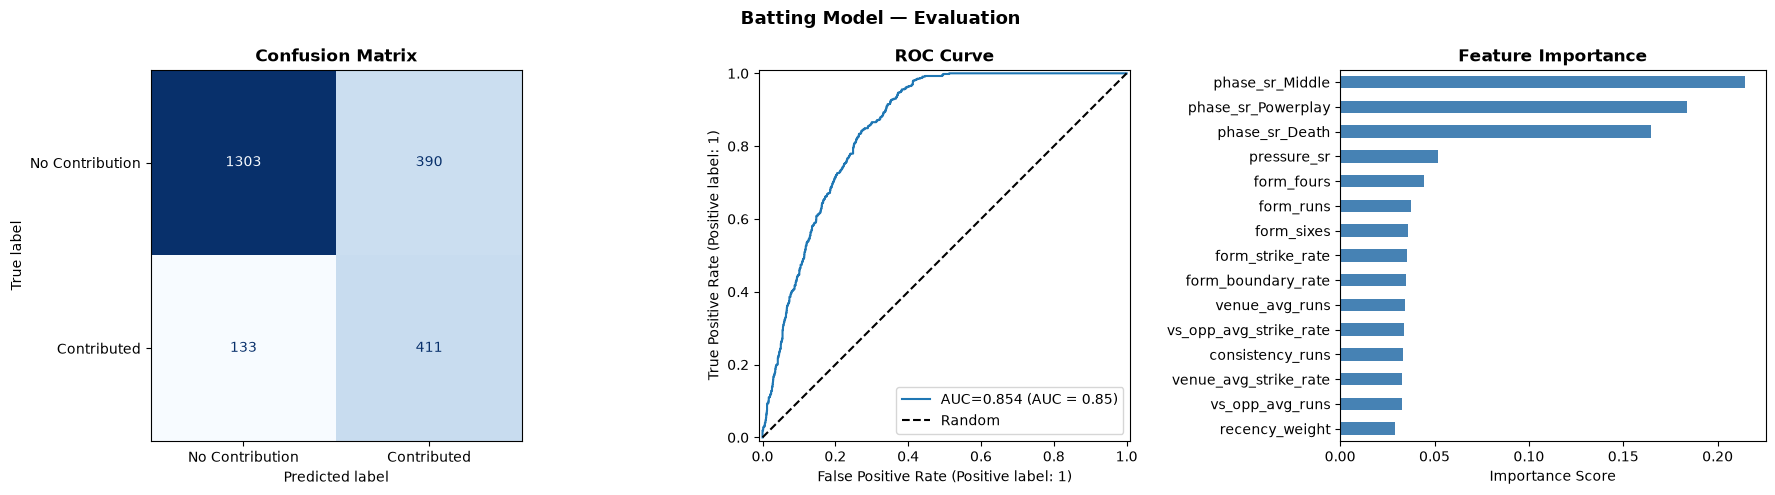

Plot saved.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Contribution', 'Contributed']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ── ROC Curve ─────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], name=f'AUC={roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# ── Feature Importance ────────────────────────────────────────────
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Batting Model — Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR + 'batting_model_evaluation.png', dpi=120)
plt.show()
print('Plot saved.')

## Step 7 — Predict Win Contribution Probability for Every Player

For each player, take their most recent feature snapshot and predict their probability of contributing to a win. This is the score that feeds the squad optimizer in Notebook 06.

In [9]:
# Latest feature snapshot per player — most recent match's feature values
latest_batting = (
    batted
    .sort_values(['player', 'season', 'match_id'])
    .groupby('player')
    .last()
    .reset_index()
)

X_latest = latest_batting[FEATURES]
latest_batting['bat_win_prob'] = model.predict_proba(X_latest)[:, 1]

bat_scores = latest_batting[['player', 'bat_win_prob', 'season']].sort_values(
    'bat_win_prob', ascending=False
).reset_index(drop=True)

print('=== TOP 20 BATSMEN BY WIN CONTRIBUTION PROBABILITY ===')
print(bat_scores.head(20).to_string(index=False))

=== TOP 20 BATSMEN BY WIN CONTRIBUTION PROBABILITY ===
         player  bat_win_prob  season
     UT Khawaja      0.900756    2016
     JG Bethell      0.889836    2025
       D Brevis      0.889094    2025
     SO Hetmyer      0.876275    2025
     RR Rossouw      0.873947    2024
B Sai Sudharsan      0.868682    2025
    Urvil Patel      0.863344    2025
 Vivrant Sharma      0.814123    2023
    NLTC Perera      0.811823    2016
      H Klaasen      0.784620    2025
       WG Jacks      0.755547    2025
        SS Iyer      0.751696    2025
       SK Raina      0.750674    2021
      JA Morkel      0.743130    2016
        TM Head      0.739007    2025
       AR Patel      0.733956    2025
     SL Malinga      0.722057    2017
         S Dube      0.692130    2025
      JM Sharma      0.688452    2025
  V Suryavanshi      0.668474    2025


## Step 8 — Save Model and Scores

In [10]:
joblib.dump(model,    MODELS_DIR + 'batting_model.pkl')
joblib.dump(FEATURES, MODELS_DIR + 'batting_features.pkl')
bat_scores.to_parquet(PROCESSED_DIR + 'batting_scores.parquet', index=False)

print('Saved:')
print(f'  models/batting_model.pkl')
print(f'  models/batting_features.pkl')
print(f'  data/processed/batting_scores.parquet')

Saved:
  models/batting_model.pkl
  models/batting_features.pkl
  data/processed/batting_scores.parquet


## Step 9 — Validation Checks

In [11]:
import os

checks = [
    ('batting_model.pkl saved',      os.path.exists(MODELS_DIR + 'batting_model.pkl')),
    ('batting_features.pkl saved',   os.path.exists(MODELS_DIR + 'batting_features.pkl')),
    ('batting_scores.parquet saved', os.path.exists(PROCESSED_DIR + 'batting_scores.parquet')),
    ('ROC-AUC above 0.55',           roc_auc > 0.55),
    ('Scores between 0 and 1',       bat_scores['bat_win_prob'].between(0, 1).all()),
    ('Scores has player column',      'player' in bat_scores.columns),
    ('More than 50 players scored',  len(bat_scores) > 50),
]

all_pass = True
for name, result in checks:
    icon = '✓' if result else '✗  FAIL'
    print(f'{icon}  {name}')
    if not result:
        all_pass = False

print(f'\n  Final ROC-AUC : {roc_auc:.4f}')
print()
if all_pass:
    print('All checks passed. Proceed to Notebook 05 — Bowling Model.')
else:
    print('Fix failing checks before proceeding.')

✓  batting_model.pkl saved
✓  batting_features.pkl saved
✓  batting_scores.parquet saved
✓  ROC-AUC above 0.55
✓  Scores between 0 and 1
✓  Scores has player column
✓  More than 50 players scored

  Final ROC-AUC : 0.8545

All checks passed. Proceed to Notebook 05 — Bowling Model.
